# 03 Measures of Central Tendency

This chapter introduces the three most common measures of central tendency:

- Mean
- Median
- Mode

You will also learn how outliers affect these statistics.

## Learning Objectives

After completing this chapter, you will be able to:

- calculate the mean, median, and mode;
- explain the differences between these measures;
- understand how outliers affect the mean;
- interpret summary statistics correctly.

## Mean

The arithmetic mean is the sum of all observations divided by the number of observations.

$$
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n}x_i
$$

## Median

The median is the middle value after sorting all observations.

For an even number of observations:

$$
\text{Median}
=
\frac{x_{(n/2)}+x_{(n/2+1)}}{2}
$$

In [1]:
## 4. Load Libraries
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## 5. Locate Project Root
current_dir = Path.cwd().resolve()

project_root = next(
    (
        p
        for p in [current_dir, *current_dir.parents]
        if (p / "data").exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Project root not found.")

data_path = project_root / "data" / "03_measures_of_central_tendency.csv"

print(data_path)

E:\Analytics\Statistical-Analytics\data\03_measures_of_central_tendency.csv


In [3]:
## 6. Load Dataset
df = pd.read_csv(data_path)

df.head()

,country_id,region,gdp_per_capita_usd
0,Country_01,Region_A,42000
1,Country_02,Region_A,45000
2,Country_03,Region_A,47000
3,Country_04,Region_A,39000
4,Country_05,Region_A,41000


In [4]:
## 7. Dataset Overview
print(df.shape)

df.info()

df.describe()

(40, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country_id          40 non-null     object
 1   region              40 non-null     object
 2   gdp_per_capita_usd  40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB


,gdp_per_capita_usd
count,40.00000
mean,34850.00000
std,36500.47418
min,12000.00000
25%,20000.00000
50%,28500.00000
75%,39500.00000
max,250000.00000


In [6]:
## 8. Calculate Mean
mean_value = df["gdp_per_capita_usd"].mean()

print(mean_value)

34850.0


In [7]:
## 9. Calculate Median
median_value = df["gdp_per_capita_usd"].median()

print(median_value)

28500.0


In [8]:
## 10. Calculate Mode
mode_value = df["gdp_per_capita_usd"].mode()

print(mode_value)

0    18000
1    19000
2    20000
3    21000
4    47000
Name: gdp_per_capita_usd, dtype: int64


In [9]:
## 11. Compare Statistics
summary = pd.DataFrame(
    {
        "Statistic": [
            "Mean",
            "Median",
            "Mode",
        ],
        "Value": [
            mean_value,
            median_value,
            mode_value.iloc[0],
        ],
    }
)

summary

,Statistic,Value
0,Mean,34850.0
1,Median,28500.0
2,Mode,18000.0


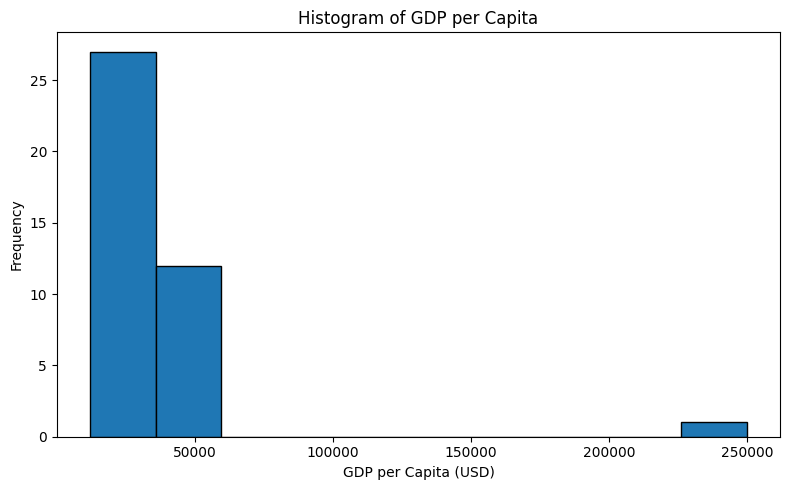

In [10]:
## 12. Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df["gdp_per_capita_usd"],
    bins=10,
    edgecolor="black",
)

plt.title("Histogram of GDP per Capita")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

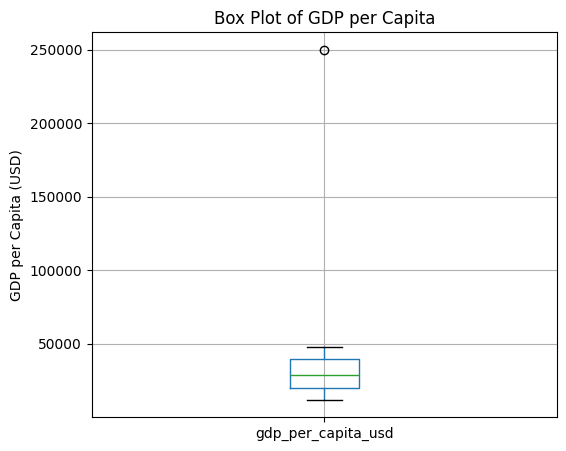

In [11]:
## 13. Box Plot
plt.figure(figsize=(6,5))

df.boxplot(column="gdp_per_capita_usd")

plt.title("Box Plot of GDP per Capita")
plt.ylabel("GDP per Capita (USD)")

plt.show()

In [12]:
## 14. Remove the Outlier
df_without_outlier = df[df["gdp_per_capita_usd"] < 100000]

print("Mean :", df_without_outlier["gdp_per_capita_usd"].mean())
print("Median :", df_without_outlier["gdp_per_capita_usd"].median())

Mean : 29333.333333333332
Median : 28000.0


## Interpretation

The mean is noticeably larger than the median because one fictional country has an exceptionally high GDP per capita.

This illustrates an important statistical principle:

- The mean is sensitive to outliers.
- The median is more robust.
- When extreme values are present, the median often provides a better measure of the center of the data.

## Exercises

### Exercise 1

Calculate the mean, median, and mode.

### Exercise 2

Remove Country_40 and calculate the statistics again.

### Exercise 3

Which statistic better represents the center of this dataset?

Explain your answer.

### Exercise 4

Compare the histogram before and after removing the outlier.

## Summary

In this chapter, you learned how to:

- calculate the mean;
- calculate the median;
- calculate the mode;
- understand the influence of outliers;
- choose an appropriate measure of central tendency.

The next chapter introduces measures of variability, which describe how spread out the data are.